# **R/S BENCHMARK — SPAGHETTI PLOT & RUL ANALYSIS**

Loads the $(R, S)$-fixed, time-swept GLD samples written by
[`05_generate_rul_dataset.ipynb`](05_generate_rul_dataset.ipynb) and:

1. draws the spaghetti plot of $g(t)$ (every Monte Carlo path, plus the mean);
2. turns each path into a failure time (`compute_rul_benchmark`, the first down-crossing of
   `threshold`, right-censored at the last time step if it never crosses) and reports the RUL
   distribution;
3. compares the $g$ distribution at a few chosen time steps; and
4. computes the **conditional** RUL given survival to a chosen time.

No emulator or NN calls here — this notebook only reads the `.pkl` written by stage 5 and plots.
Same figure conventions as [`01_plot_lambda_maps.ipynb`](01_plot_lambda_maps.ipynb): separate
figures, no titles (captions belong in the LaTeX), configurable size/fonts/dpi, each saved next to
the data it came from.

## 1. Libraries

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd
import seaborn as sns

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import dill

from functions import compute_rul_benchmark

## 2. Config

`n_latent_samples`, `r_fixed` and `s_fixed` must match
[`05_generate_rul_dataset.ipynb`](05_generate_rul_dataset.ipynb) — together they name the file
being loaded.

`threshold` is the failure level on $g$ (failure is $g \le$ `threshold`).

In [38]:
n_latent_samples = 2500   # must match stage 5 — it names the file being loaded
r_fixed = 5.0             # must match stage 5
s_fixed = 2.0             # must match stage 5

# Intervention threshold on the state limit function. The end of useful life is taken as
# g <= threshold, NOT necessarily g <= 0: in practice nobody waits for the attack front to
# reach the reinforcement before intervening, so a positive threshold expresses a preventive
# maintenance policy ("act while there are still `threshold` units of margin left").
# threshold = 0 recovers the classical time-to-failure.
threshold       = 0.7
threshold_sweep = [0.0, 0.25, 0.5, 0.75, 1.0]   # policies compared in section 8

fig_size   = (6, 4.5)    # size of each individual figure, in inches
fig_format = 'png'       # format each figure is saved in ('pdf', 'png', ...)
fig_dpi    = 300         # resolution the figure is saved at (dots per inch)

label_fontsize = 14   # font size of the axis labels
tick_fontsize  = 12   # font size of the tick numbers

xlim = None   # e.g. (0, 150) to fix the time axis; None = auto-scaled to the data
ylim = None   # e.g. (-15, 15) to fix the g axis; None = auto-scaled to the data

n_paths_plotted = 300   # spaghetti lines drawn (all n_glam_samples would be far too many to render)
random_state    = 42

## 3. Load the RUL dataset

In [39]:
tag      = f'R{r_fixed:g}_S{s_fixed:g}_benchmark'
pkl_name = f'{n_latent_samples}_rul_samples_{tag}'

with open(f'{n_latent_samples}_rul_lambdas_{tag}.pkl', 'rb') as f:
    lambda_df = dill.load(f)
with open(f'{pkl_name}.pkl', 'rb') as f:
    samples = dill.load(f)

times = lambda_df['Time (years)'].to_numpy()
print(f"Loaded samples: {samples.shape[0]} paths x {samples.shape[1]} time steps")
lambda_df

Loaded samples: 50000 paths x 20 time steps


,r,s,Time (years),lambda 1,lambda 2,lambda 3,lambda 4
0,5.0,2.0,0.000000,2.995682,6.128036,0.142157,0.131525
1,5.0,2.0,5.263158,2.866417,6.175774,0.142157,0.131525
2,5.0,2.0,10.526316,2.738662,6.199467,0.142157,0.131525
3,5.0,2.0,15.789474,2.608061,6.260498,0.142157,0.131525
4,5.0,2.0,21.052632,2.468088,6.360435,0.142157,0.131525
5,5.0,2.0,26.315789,2.344785,6.426558,0.142157,0.131525
6,5.0,2.0,31.578947,2.218716,6.452731,0.142157,0.131525
7,5.0,2.0,36.842105,2.082385,6.482594,0.142157,0.131525
8,5.0,2.0,42.105263,1.940453,6.558748,0.142157,0.131525
9,5.0,2.0,47.368421,1.813681,6.642764,0.142157,0.131525


## 4. Spaghetti plot

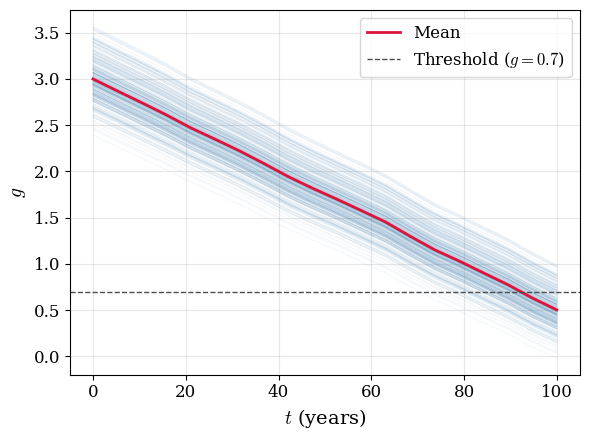

In [40]:
rng           = np.random.default_rng(random_state)
plotted_idx   = rng.choice(samples.shape[0], size=min(n_paths_plotted, samples.shape[0]), replace=False)

fig, ax = plt.subplots(figsize=fig_size)
for i in plotted_idx:
    ax.plot(times, samples[i], color='steelblue', alpha=0.08, linewidth=0.6)
ax.plot(times, samples.mean(axis=0), color='crimson', linewidth=2, label='Mean')
ax.axhline(threshold, color='0.3', linestyle='--', linewidth=1, label=f'Threshold ($g={threshold:g}$)')

ax.set_xlabel('$t$ (years)', fontsize=label_fontsize)
ax.set_ylabel('$g$', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_spaghetti.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 4.1 Mesmo gráfico, em português

Para uso no artigo. Salvo como `<pkl_name>_spaghetti_pt.<fig_format>`.

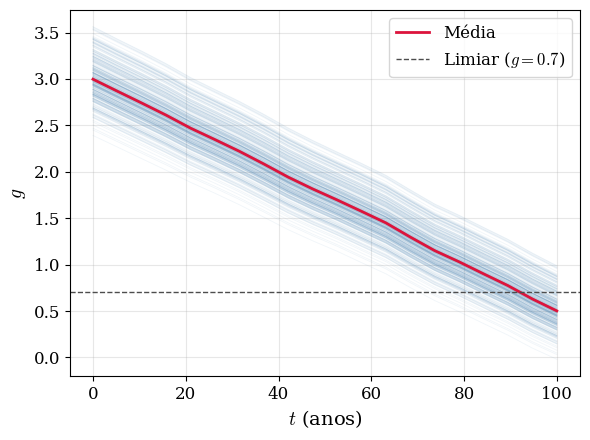

In [41]:
fig, ax = plt.subplots(figsize=fig_size)
for i in plotted_idx:
    ax.plot(times, samples[i], color='steelblue', alpha=0.08, linewidth=0.6)
ax.plot(times, samples.mean(axis=0), color='crimson', linewidth=2, label='Média')
ax.axhline(threshold, color='0.3', linestyle='--', linewidth=1, label=f'Limiar ($g={threshold:g}$)')

ax.set_xlabel('$t$ (anos)', fontsize=label_fontsize)
ax.set_ylabel('$g$', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_spaghetti_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## 5. RUL — time to failure

`compute_rul_benchmark` finds, for every Monte Carlo path, the first time $g$ drops to or below
`threshold` (linear interpolation between the two straddling time steps). A path that never crosses
is right-censored at `times[-1]` — check `n_censored` below before trusting the tail of the
distribution: heavy censoring means the time grid in stage 5 didn't reach far enough.

In [42]:
failure_times = compute_rul_benchmark(samples, times, threshold=threshold)
n_censored    = int(np.sum(failure_times == times[-1]))

print(f"Failure times: {len(failure_times)} paths ({n_censored} right-censored at t={times[-1]:.1f})")
print(f"  Mean:   {failure_times.mean():.2f}")
print(f"  Median: {np.median(failure_times):.2f}")
print(f"  Std:    {failure_times.std():.2f}")
print(f"  P5:     {np.percentile(failure_times, 5):.2f}")
print(f"  P95:    {np.percentile(failure_times, 95):.2f}")

Failure times: 50000 paths (8221 right-censored at t=100.0)
  Mean:   91.32
  Median: 92.18
  Std:    7.13
  P5:     78.19
  P95:    100.00


### 5.1 RUL probability density

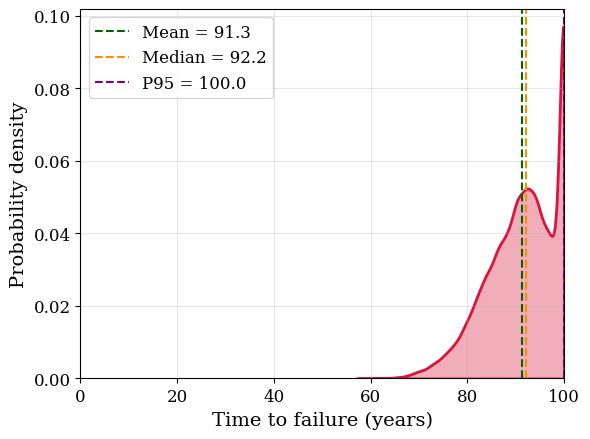

In [43]:
fig, ax = plt.subplots(figsize=fig_size)
sns.kdeplot(failure_times, ax=ax, color='crimson', linewidth=2, fill=True, alpha=0.35, clip=(0, times[-1]))

for value, label, color in [(failure_times.mean(), 'Mean', 'darkgreen'),
                             (np.median(failure_times), 'Median', 'darkorange'),
                             (np.percentile(failure_times, 95), 'P95', 'purple')]:
    ax.axvline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label} = {value:.1f}')

ax.set_xlim(0, times[-1])
ax.set_xlabel('Time to failure (years)', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_rul_pdf.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 5.2 Mesmo gráfico, em português

Para uso no artigo. Salvo como `<pkl_name>_rul_pdf_pt.<fig_format>`.

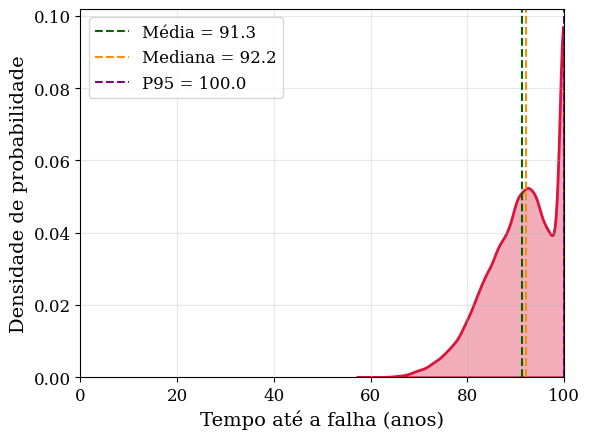

In [44]:
fig, ax = plt.subplots(figsize=fig_size)
sns.kdeplot(failure_times, ax=ax, color='crimson', linewidth=2, fill=True, alpha=0.35, clip=(0, times[-1]))

for value, label, color in [(failure_times.mean(), 'Média', 'darkgreen'),
                             (np.median(failure_times), 'Mediana', 'darkorange'),
                             (np.percentile(failure_times, 95), 'P95', 'purple')]:
    ax.axvline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label} = {value:.1f}')

ax.set_xlim(0, times[-1])
ax.set_xlabel('Tempo até a falha (anos)', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_rul_pdf_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## 6. $g$ distribution at a few time steps

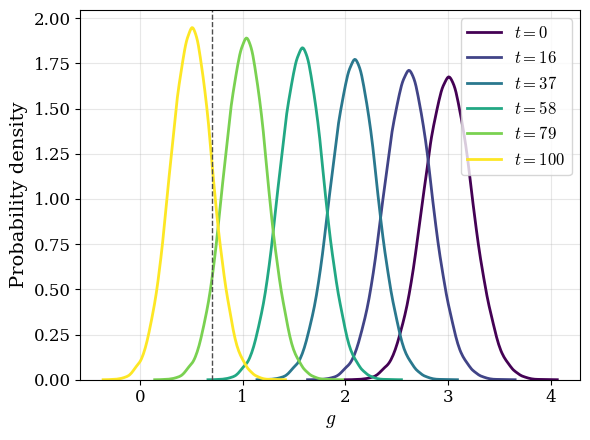

In [45]:
time_indices = np.linspace(0, len(times) - 1, min(6, len(times)), dtype=int)

fig, ax = plt.subplots(figsize=fig_size)
colors = plt.cm.viridis(np.linspace(0, 1, len(time_indices)))
for idx, color in zip(time_indices, colors):
    sns.kdeplot(samples[:, idx], ax=ax, color=color, linewidth=2, label=f'$t={times[idx]:.0f}$')

ax.axvline(threshold, color='0.3', linestyle='--', linewidth=1)
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_g_pdfs.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 6.1 Mesmo gráfico, em português

Para uso no artigo. Salvo como `<pkl_name>_g_pdfs_pt.<fig_format>`.

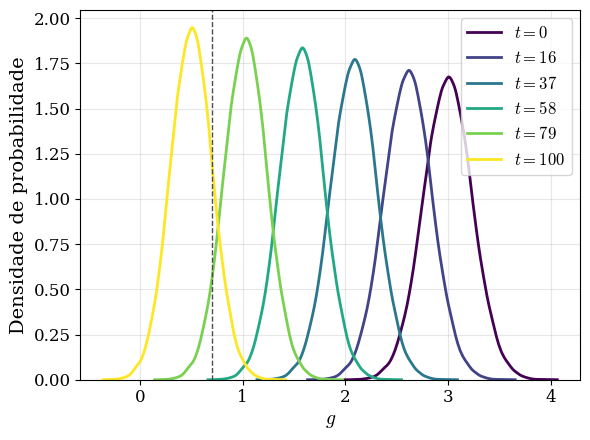

In [46]:
fig, ax = plt.subplots(figsize=fig_size)
colors = plt.cm.viridis(np.linspace(0, 1, len(time_indices)))
for idx, color in zip(time_indices, colors):
    sns.kdeplot(samples[:, idx], ax=ax, color=color, linewidth=2, label=f'$t={times[idx]:.0f}$')

ax.axvline(threshold, color='0.3', linestyle='--', linewidth=1)
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.legend(fontsize=tick_fontsize)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_g_pdfs_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## 7. Conditional RUL — given survival to a chosen time

Restricts to paths that are still above `threshold` at `time_query`, and reports **RUL from
`time_query`** (not from $t=0$) for those survivors: $\mathrm{RUL} = t_{\text{failure}} -
\text{time\_query}$.

`time_query` need not land on the simulated time grid: `g` at that instant is obtained by linear
interpolation between the two straddling grid points (`times` has only 20 entries, so e.g.
`time_query = 50` would otherwise silently snap to whichever grid point is closest — 47.4, not 50,
since `np.argmin` breaks the exact tie between 47.4 and 52.6 by picking the earlier one).

In [ ]:
time_query = 50.0   # condition on survival up to this time (interpolated, need not sit on the time grid)

idx_hi     = int(np.clip(np.searchsorted(times, time_query, side='right'), 1, len(times) - 1))
idx_lo     = idx_hi - 1
frac       = (time_query - times[idx_lo]) / (times[idx_hi] - times[idx_lo])
g_at_query = samples[:, idx_lo] + frac * (samples[:, idx_hi] - samples[:, idx_lo])

survivors_mask = g_at_query > threshold
print(f"Survivors at t={time_query:.1f}: {survivors_mask.sum()} / {len(survivors_mask)}")

if survivors_mask.sum() == 0:
    print("No surviving paths at this time — pick an earlier time_query.")
else:
    failure_times_survivors = compute_rul_benchmark(samples[survivors_mask], times, threshold=threshold)
    conditional_rul = failure_times_survivors[failure_times_survivors > time_query] - time_query
    rul_horizon = times[-1] - time_query   # longest RUL reachable within the simulated horizon

    fig, ax = plt.subplots(figsize=fig_size)
    sns.kdeplot(conditional_rul, ax=ax, color='darkgreen', linewidth=2, fill=True, alpha=0.35, clip=(0, rul_horizon))

    for value, label, color in [(conditional_rul.mean(), 'Mean', 'crimson'),
                                 (np.median(conditional_rul), 'Median', 'darkorange'),
                                 (np.percentile(conditional_rul, 95), 'P95', 'purple')]:
        ax.axvline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label} = {value:.1f}')

    ax.set_xlim(0, rul_horizon)
    ax.set_xlabel(f'RUL from $t={time_query:.0f}$ (years)', fontsize=label_fontsize)
    ax.set_ylabel('Probability density', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.legend(fontsize=tick_fontsize)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig.savefig(f'{pkl_name}_conditional_rul_t{time_query:.0f}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    plt.show()

    print(f"\nConditional RUL from t={time_query:.1f}:")
    print(f"  Mean:   {conditional_rul.mean():.2f}")
    print(f"  Median: {np.median(conditional_rul):.2f}")
    print(f"  P95:    {np.percentile(conditional_rul, 95):.2f}")

### 7.1 Mesmo gráfico, em português

Para uso no artigo. Salvo como `<pkl_name>_conditional_rul_t<idx>_pt.<fig_format>`.

In [ ]:
if survivors_mask.sum() == 0:
    print("Nenhuma trajetória sobrevivente nesse instante — escolha um time_query mais cedo.")
else:
    fig, ax = plt.subplots(figsize=fig_size)
    sns.kdeplot(conditional_rul, ax=ax, color='darkgreen', linewidth=2, fill=True, alpha=0.35, clip=(0, rul_horizon))

    for value, label, color in [(conditional_rul.mean(), 'Média', 'crimson'),
                                 (np.median(conditional_rul), 'Mediana', 'darkorange'),
                                 (np.percentile(conditional_rul, 95), 'P95', 'purple')]:
        ax.axvline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label} = {value:.1f}')

    ax.set_xlim(0, rul_horizon)
    ax.set_xlabel(f'RUL a partir de $t={time_query:.0f}$ (anos)', fontsize=label_fontsize)
    ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.legend(fontsize=tick_fontsize)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig.savefig(f'{pkl_name}_conditional_rul_t{time_query:.0f}_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    plt.show()

## 8. Threshold sweep — remaining life as a function of the maintenance policy

The threshold is a **decision variable**, not a property of the structure. Raising it means
intervening earlier, with more margin left; lowering it towards zero means running the asset until
the limit state is actually reached.

Sweeping it turns a single RUL distribution into a family of them, one per policy — which is the
input a maintenance-scheduling optimisation consumes. Two columns matter for whether a given
policy is even estimable from this horizon: `reached (%)`, the share of paths that hit the
threshold before `times[-1]`, and its complement, the **censored** share, whose remaining life is
only known to exceed the horizon.

In [49]:
rows = []
for g_lim in threshold_sweep:
    ft       = compute_rul_benchmark(samples, times, threshold=g_lim)
    censored = ft >= times[-1]
    reached  = ~censored
    rows.append({'threshold': g_lim,
                 'reached (%)': reached.mean() * 100,
                 'censored (%)': censored.mean() * 100,
                 'mean (years)': ft[reached].mean() if reached.any() else np.nan,
                 'P5 (years)': np.percentile(ft[reached], 5) if reached.any() else np.nan,
                 'P50 (years)': np.percentile(ft[reached], 50) if reached.any() else np.nan})

sweep = pd.DataFrame(rows)
print('Statistics are computed over the paths that actually reach the threshold;')
print('a large censored share means the horizon is too short to characterise that policy.\n')
sweep.round(2)

Statistics are computed over the paths that actually reach the threshold;
a large censored share means the horizon is too short to characterise that policy.



,threshold,reached (%),censored (%),mean (years),P5 (years),P50 (years)
0,0.00,0.75,99.25,97.29,92.57,97.99
1,0.25,10.88,89.12,95.84,88.87,96.73
2,0.50,49.56,50.44,93.37,83.66,94.27
3,0.75,88.83,11.17,88.30,75.45,89.24
4,1.00,99.15,0.85,79.89,66.46,80.10


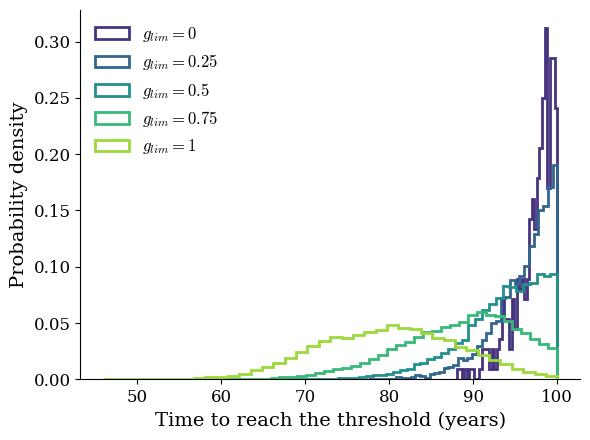

In [50]:
fig, ax = plt.subplots(figsize=fig_size)

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(threshold_sweep)))
for g_lim, color in zip(threshold_sweep, colors):
    ft      = compute_rul_benchmark(samples, times, threshold=g_lim)
    reached = ft < times[-1]
    if reached.sum() > 10:
        ax.hist(ft[reached], bins=40, density=True, histtype='step', linewidth=2.0,
                color=color, label=f'$g_{{lim}} = {g_lim:g}$')

ax.set_xlabel('Time to reach the threshold (years)', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(labelsize=tick_fontsize)
ax.legend(frameon=False, fontsize=tick_fontsize)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
fig.tight_layout()
fig.savefig(f'z_rul_threshold_sweep_{tag}.{fig_format}', dpi=fig_dpi, bbox_inches='tight')
plt.show()